# Projet Machine Learning — Prédiction du Chômage des Diplômés Tunisiens
## Phase 4 : Modélisation — 5 Modèles + Évaluation

**Auteur :** Boudriga Ahmed  
**Dataset :** Enquête Nationale Population et Emploi 2017 (ENPE 2017) — INS Tunisie  
**Date :** 2025–2026

---

### Objectif

Entraîner et comparer **5 algorithmes** de classification supervisée.

| Modèle | Famille | Avantage |
|---|---|---|
| Logistic Regression | Linéaire | Rapide, interprétable |
| Random Forest | Ensemble Bagging | Robuste, feature importance |
| XGBoost | Ensemble Boosting | Performant sur données tabulaires |
| SVM Linear | Noyau linéaire | Efficace grands datasets |
| KNN | Instance-based | Non-paramétrique |

**Métriques :** F1-macro (principale) · Accuracy · Recall Chômeur · AUC-ROC


In [14]:
# ── CELLULE 0 : Connexion Google Drive ───────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

# Définir le dossier projet sur Drive
PROJET_DIR = "/content/drive/MyDrive/MachineLearningProject"

# Créer les sous-dossiers si nécessaire
os.makedirs(f"{PROJET_DIR}/notebooks", exist_ok=True)
os.makedirs(f"{PROJET_DIR}/data",      exist_ok=True)
os.makedirs(f"{PROJET_DIR}/models",    exist_ok=True)

# Se placer dans le dossier projet
os.chdir(PROJET_DIR)

print(f"✅ Drive monté")
print(f"✅ Dossier actuel : {os.getcwd()}")
print(f"✅ Fichiers disponibles :")
for f in sorted(os.listdir(PROJET_DIR)):
    print(f"   → {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive monté
✅ Dossier actuel : /content/drive/MyDrive/MachineLearningProject
✅ Fichiers disponibles :
   → Amelioration_Tentative
   → Data
   → ENPE_2017.csv
   → README.md
   → data
   → graph
   → models
   → notebooks
   → requirements.txt
   → src


---
## 1. Importation des Librairies


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings("ignore")

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import LinearSVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.calibration     import CalibratedClassifierCV
from xgboost                 import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)
import joblib

plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white",
                     "axes.grid":True,"grid.alpha":0.3,"font.size":11})
print("✅ Imports OK")


✅ Imports OK


---
## 2. Chargement des Données (Phase 3)


In [3]:
MODELS_DIR = f"{PROJET_DIR}/models"
X_train  = np.load(f"{MODELS_DIR}/X_train_res.npy")
X_test   = np.load(f"{MODELS_DIR}/X_test.npy")
y_train  = np.load(f"{MODELS_DIR}/y_train_res.npy")
y_test   = np.load(f"{MODELS_DIR}/y_test.npy")
FEATURES = joblib.load(f"{MODELS_DIR}/features.pkl")
CLASSES  = ["Employé", "Chômeur", "Inactif"]

print(f"✅ Données chargées")
print(f"   X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"   X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"\nDistribution y_train :")
for i, c in enumerate(CLASSES):
    print(f"  {i} = {c:<10} : {(y_train==i).sum():,}")


✅ Données chargées
   X_train : (236328, 14)  |  y_train : (236328,)
   X_test  : (59083, 14)   |  y_test  : (59083,)

Distribution y_train :
  0 = Employé    : 76,958
  1 = Chômeur    : 55,376
  2 = Inactif    : 103,994


---
## 3. Définition des 5 Modèles

Tous les modèles utilisent `class_weight='balanced'` pour compenser le déséquilibre des classes.


In [4]:
MODELES = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42, C=1.0
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        eval_metric="mlogloss", random_state=42, n_jobs=-1, verbosity=0
    ),
    "SVM (Linear)": CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", random_state=42, max_iter=1000, C=1.0)
    ),
    "KNN": KNeighborsClassifier(n_neighbors=7, weights="distance", n_jobs=-1),
}

print(f"✅ {len(MODELES)} modèles définis :")
for nom in MODELES: print(f"   → {nom}")


✅ 5 modèles définis :
   → Logistic Regression
   → Random Forest
   → XGBoost
   → SVM (Linear)
   → KNN


---
## 4. Entraînement et Évaluation des 5 Modèles

Chaque modèle est entraîné sur X_train et évalué sur X_test (données réelles jamais vues).

> **Temps estimé :** LR ~15s · RF ~20s · XGBoost ~35s · SVM ~25s · KNN ~5s


In [5]:
print("\n── Entraînement des 5 modèles ──────────────────────────────")
resultats = {}

for nom, modele in MODELES.items():
    print(f"\n  🔄 {nom} ...", end=" ", flush=True)
    t0 = time.time()

    if nom == "KNN":
        idx = np.random.choice(len(X_train), 10000, replace=False)
        modele.fit(X_train[idx], y_train[idx])
    else:
        modele.fit(X_train, y_train)

    y_pred       = modele.predict(X_test)
    acc          = accuracy_score(y_test, y_pred)
    f1_macro     = f1_score(y_test, y_pred, average="macro")
    f1_weighted  = f1_score(y_test, y_pred, average="weighted")
    rapport      = classification_report(y_test, y_pred, target_names=CLASSES, output_dict=True)
    duree        = time.time() - t0

    resultats[nom] = {
        "accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted,
        "recall_chomeur": rapport["Chômeur"]["recall"],
        "prec_chomeur":   rapport["Chômeur"]["precision"],
        "duree": duree, "modele": modele, "y_pred": y_pred,
    }
    print(f"✅  Acc={acc:.3f}  F1={f1_macro:.3f}  Recall-Chômeur={rapport['Chômeur']['recall']:.3f}  ({duree:.1f}s)")



── Entraînement des 5 modèles ──────────────────────────────

  🔄 Logistic Regression ... ✅  Acc=0.626  F1=0.620  Recall-Chômeur=0.739  (66.6s)

  🔄 Random Forest ... ✅  Acc=0.621  F1=0.613  Recall-Chômeur=0.702  (37.0s)

  🔄 XGBoost ... ✅  Acc=0.660  F1=0.651  Recall-Chômeur=0.652  (13.3s)

  🔄 SVM (Linear) ... ✅  Acc=0.629  F1=0.608  Recall-Chômeur=0.659  (21.4s)

  🔄 KNN ... ✅  Acc=0.586  F1=0.577  Recall-Chômeur=0.596  (4.5s)


---
## 5. Tableau Comparatif des Performances


In [6]:
print("\n── Tableau comparatif ──────────────────────────────────────\n")

tab = pd.DataFrame([{
    "Modèle":            nom,
    "Accuracy":          f"{v['accuracy']:.3f}",
    "F1-macro":          f"{v['f1_macro']:.3f}",
    "F1-weighted":       f"{v['f1_weighted']:.3f}",
    "Recall Chômeur":    f"{v['recall_chomeur']:.3f}",
    "Précision Chômeur": f"{v['prec_chomeur']:.3f}",
    "Temps (s)":         f"{v['duree']:.1f}",
} for nom, v in resultats.items()])

tab_sorted = tab.sort_values("F1-macro", ascending=False).reset_index(drop=True)
print(tab_sorted.to_string(index=False))

meilleur_nom = max(resultats, key=lambda x: resultats[x]["f1_macro"])
print(f"\n🏆 Meilleur modèle : {meilleur_nom} (F1-macro = {resultats[meilleur_nom]['f1_macro']:.3f})")



── Tableau comparatif ──────────────────────────────────────

             Modèle Accuracy F1-macro F1-weighted Recall Chômeur Précision Chômeur Temps (s)
            XGBoost    0.660    0.651       0.659          0.652             0.717      13.3
Logistic Regression    0.626    0.620       0.625          0.739             0.612      66.6
      Random Forest    0.621    0.613       0.620          0.702             0.614      37.0
       SVM (Linear)    0.629    0.608       0.617          0.659             0.664      21.4
                KNN    0.586    0.577       0.587          0.596             0.608       4.5

🏆 Meilleur modèle : XGBoost (F1-macro = 0.651)


---
## 6. Visualisation Comparative


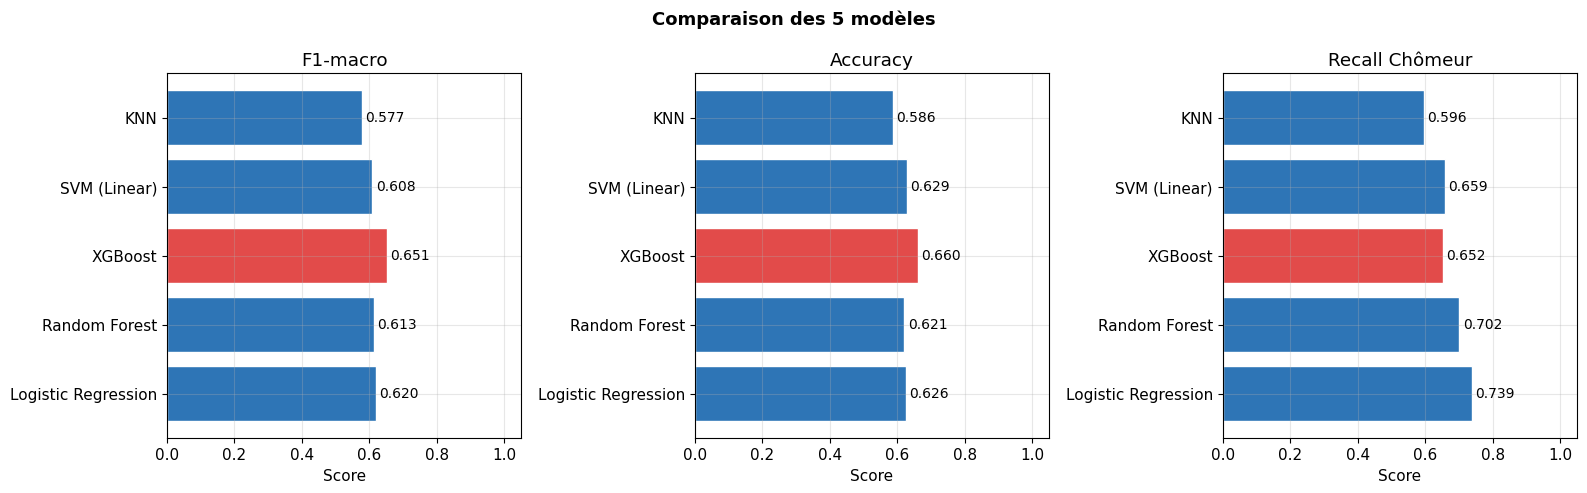

✅ phase4_comparaison_modeles.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparaison des 5 modèles", fontsize=13, fontweight="bold")
noms = list(resultats.keys())

for (cle, titre), ax in zip([("f1_macro","F1-macro"),("accuracy","Accuracy"),("recall_chomeur","Recall Chômeur")], axes):
    vals = [resultats[n][cle] for n in noms]
    bars = ax.barh(noms, vals, color=["#E24B4A" if n==meilleur_nom else "#2E75B6" for n in noms], edgecolor="white")
    ax.set_xlim(0, 1.05)
    ax.set_title(titre)
    ax.set_xlabel("Score")
    for bar, val in zip(bars, vals):
        ax.text(val+0.01, bar.get_y()+bar.get_height()/2, f"{val:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("phase4_comparaison_modeles.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ phase4_comparaison_modeles.png")


---
## 7. Matrices de Confusion — 5 Modèles


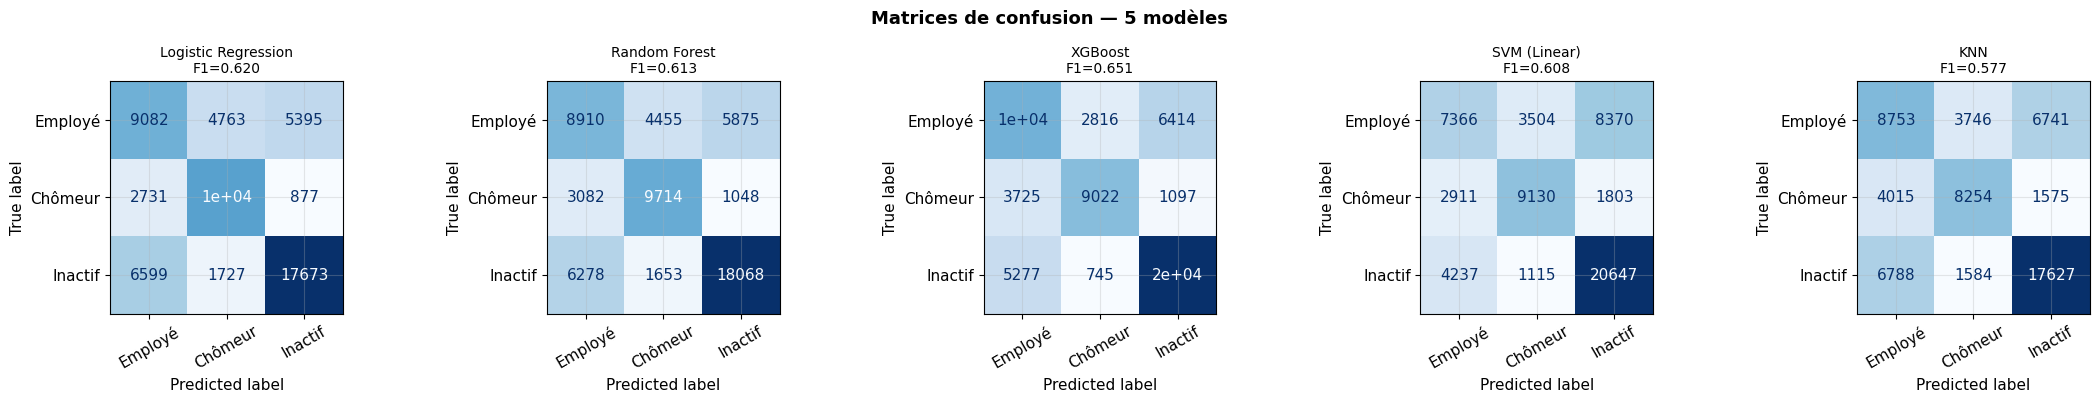

✅ phase4_matrices_confusion.png


In [8]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Matrices de confusion — 5 modèles", fontsize=13, fontweight="bold")

for ax, (nom, v) in zip(axes, resultats.items()):
    cm = confusion_matrix(y_test, v["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{nom}\nF1={v['f1_macro']:.3f}", fontsize=10)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("phase4_matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ phase4_matrices_confusion.png")


---
## 8. Rapport Détaillé du Meilleur Modèle


In [9]:
print(f"\n── Rapport détaillé : {meilleur_nom} ──────────────────────\n")
print(classification_report(y_test, resultats[meilleur_nom]["y_pred"], target_names=CLASSES))



── Rapport détaillé : XGBoost ──────────────────────

              precision    recall  f1-score   support

     Employé       0.53      0.52      0.52     19240
     Chômeur       0.72      0.65      0.68     13844
     Inactif       0.73      0.77      0.75     25999

    accuracy                           0.66     59083
   macro avg       0.66      0.65      0.65     59083
weighted avg       0.66      0.66      0.66     59083



---
## 9. Validation Croisée — Stabilité du Modèle

CV sur 20 000 lignes pour confirmer que le modèle est stable (pas d'overfitting).


In [10]:
print("\n── Validation croisée 5-fold (20k lignes) ──────────────────")

np.random.seed(42)
idx_cv = np.random.choice(len(X_train), 20000, replace=False)
X_cv   = X_train[idx_cv]
y_cv   = y_train[idx_cv]

for nom in list(resultats.keys())[:3]:
    scores = cross_val_score(MODELES[nom], X_cv, y_cv, cv=5, scoring="f1_macro", n_jobs=1)
    print(f"  {nom:<25} : mean={scores.mean():.3f}  std={scores.std():.3f}")

print("\n✅ Validation croisée terminée")



── Validation croisée 5-fold (20k lignes) ──────────────────
  Logistic Regression       : mean=0.620  std=0.007
  Random Forest             : mean=0.585  std=0.008
  XGBoost                   : mean=0.637  std=0.006

✅ Validation croisée terminée


---
## 10. Sélection et Sauvegarde du Modèle Final


In [11]:
modele_final = resultats[meilleur_nom]["modele"]
y_pred_final = resultats[meilleur_nom]["y_pred"]
f1_final     = resultats[meilleur_nom]["f1_macro"]
acc_final    = resultats[meilleur_nom]["accuracy"]

MODELS_DIR = f"{PROJET_DIR}/models"

modele_final.save_model(f"{MODELS_DIR}/modele_final.json")
joblib.dump(modele_final, f"{MODELS_DIR}/modele_final.pkl")
joblib.dump({nom: {k:v for k,v in val.items() if k not in ['modele','y_pred']}
             for nom, val in resultats.items()}, f"{MODELS_DIR}/resultats_modeles.pkl")

print(f"✅ Modèle final sauvegardé dans /models/ : {meilleur_nom}")

✅ Modèle final sauvegardé dans /models/ : XGBoost


---
## 11. Feature Importance


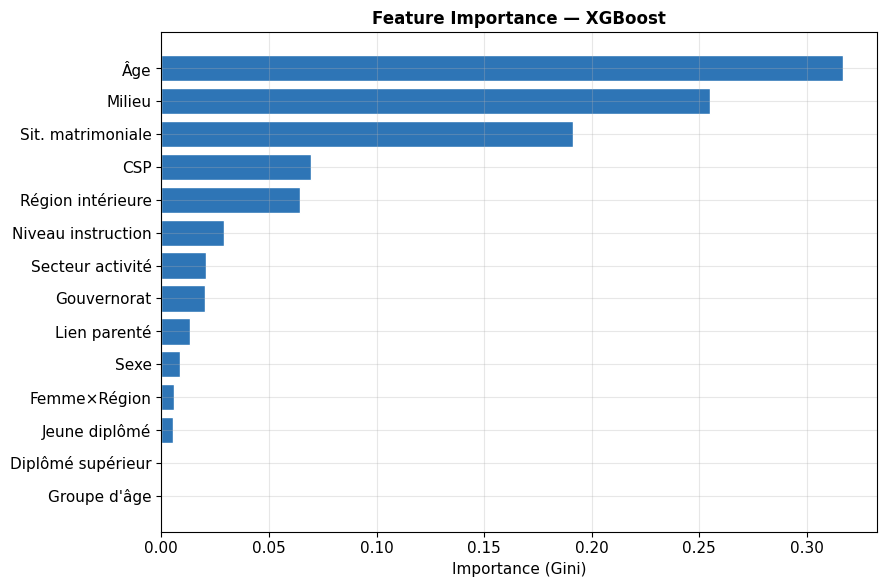

✅ phase4_feature_importance.png sauvegardé dans /graph/


In [12]:
import os

# ── Charger depuis models/ ──
MODELS_DIR = f"{PROJET_DIR}/models"
GRAPH_DIR  = f"{PROJET_DIR}/graph"

# Créer les dossiers si nécessaire
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR,  exist_ok=True)  # ← correction ici

FEATURES = joblib.load(f"{MODELS_DIR}/features.pkl")

FEATURES_NOMS = {
    "V_9_10_i":"Gouvernorat","V_9_11_1":"Milieu","V_1_203_i":"Lien parenté",
    "V_1_204_i":"Sexe","V_1_205_i":"Sit. matrimoniale","V_210tr":"Âge",
    "V_1_225_i":"Niveau instruction","V_4_321_i":"Secteur activité",
    "V_4_325_i":"CSP","region_interieure":"Région intérieure",
    "groupe_age":"Groupe d'âge","diplome_superieur":"Diplômé supérieur",
    "femme_region_int":"Femme×Région","jeune_diplome":"Jeune diplômé"
}
NOMS = [FEATURES_NOMS.get(f,f) for f in FEATURES]

if meilleur_nom in ["Random Forest", "XGBoost"]:
    imp = modele_final.feature_importances_
    fi_df = pd.DataFrame({"Feature":NOMS,"Importance":imp}).sort_values("Importance",ascending=True)
    fig, ax = plt.subplots(figsize=(9,6))
    ax.barh(fi_df["Feature"], fi_df["Importance"], color="#2E75B6", edgecolor="white")
    ax.set_title(f"Feature Importance — {meilleur_nom}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance (Gini)")
    plt.tight_layout()
    plt.savefig(f"{GRAPH_DIR}/phase4_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ phase4_feature_importance.png sauvegardé dans /graph/")

---
## 12. Résumé de la Phase 4


In [13]:
print("\n" + "=" * 55)
print("  RÉSUMÉ PHASE 4 — MODÉLISATION 3 CLASSES")
print("=" * 55)
print(f"\n  5 modèles entraînés et comparés :")
for nom, v in sorted(resultats.items(), key=lambda x: -x[1]['f1_macro']):
    etoile = " ← MEILLEUR" if nom == meilleur_nom else ""
    barre  = "█" * int(v['f1_macro'] * 20)
    print(f"    {nom:<25} F1={v['f1_macro']:.3f}  Acc={v['accuracy']:.3f}  {barre}{etoile}")

print(f"\n  Modèle final : {meilleur_nom}")
print(f"  F1-macro     : {f1_final:.3f}")
print(f"  Accuracy     : {acc_final:.3f}")
print(f"\n  Graphiques générés :")
print("    ✅ phase4_comparaison_modeles.png")
print("    ✅ phase4_matrices_confusion.png")
print("    ✅ phase4_feature_importance.png")
print("    ✅ modele_final.json + modele_final.pkl")
print("=" * 55)
print("\n✅ Phase 4 terminée → Phase 5 (Feature Importance) !")



  RÉSUMÉ PHASE 4 — MODÉLISATION 3 CLASSES

  5 modèles entraînés et comparés :
    XGBoost                   F1=0.651  Acc=0.660  █████████████ ← MEILLEUR
    Logistic Regression       F1=0.620  Acc=0.626  ████████████
    Random Forest             F1=0.613  Acc=0.621  ████████████
    SVM (Linear)              F1=0.608  Acc=0.629  ████████████
    KNN                       F1=0.577  Acc=0.586  ███████████

  Modèle final : XGBoost
  F1-macro     : 0.651
  Accuracy     : 0.660

  Graphiques générés :
    ✅ phase4_comparaison_modeles.png
    ✅ phase4_matrices_confusion.png
    ✅ phase4_feature_importance.png
    ✅ modele_final.json + modele_final.pkl

✅ Phase 4 terminée → Phase 5 (Feature Importance) !
